In [88]:
#import required libraries

import torch 
import torchvision
import torch.nn as nn
import matplotlib.pyplot as plt

In [89]:
# Download and prepare the MNIST dataset

train_dataset = torchvision.datasets.MNIST(root='data/', train=True, transform=torchvision.transforms.ToTensor(), download=True)
val_dataset = torchvision.datasets.MNIST(root='data/', train=False, transform=torchvision.transforms.ToTensor(), download=True)

In [90]:
# Define variables

BATCH_SIZE = 64
NUM_CLASSES = 10
PATCH_SIZE = 7
IMG_SIZE = 28
NUM_CHANNELS = 1
PATCH_NUM = (IMG_SIZE // PATCH_SIZE) ** 2
NUM_EPOCHS = 15
ATTENTION_HEADS = 4
EMBED_DIM = 64
NUM_TRANSFORMER_BLOCKS = 4
MLP_NODES = 256
LEARNING_RATE = 3e-4

In [91]:
# Create the dataloaders 

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = torch.utils.data.DataLoader(dataset=val_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [92]:
# Class for the Patch Embedding

class PatchEmbedding(nn.Module):
    def __init__(self):
        super(PatchEmbedding, self).__init__()
        self.patch_embed = nn.Conv2d(in_channels=NUM_CHANNELS, out_channels=EMBED_DIM, kernel_size=PATCH_SIZE, stride=PATCH_SIZE)

    def forward(self, x):
        x = self.patch_embed(x) # (B, EMBED_DIM, PATCH_NUM**0.5, PATCH_NUM**0.5)
        x = x.flatten(2) # (B, EMBED_DIM, PATCH_NUM)
        x = x.transpose(1, 2) # (B, PATCH_NUM, EMBED_DIM)
        return x

In [93]:
# Class for Transformer encoder 
# Layer normalization 
# Multi-head self-attention
# Layer normalization 
# residual connection
#MLP-activation function 

class Transformer(nn.Module):
    def __init__(self): 
        super(Transformer, self).__init__()
        self.layer_norm1 = nn.LayerNorm(EMBED_DIM)
        self.self_attn = nn.MultiheadAttention(EMBED_DIM, ATTENTION_HEADS, batch_first=True)
        self.layer_norm2 = nn.LayerNorm(EMBED_DIM)
        self.mlp = nn.Sequential(
            nn.Linear(EMBED_DIM, MLP_NODES),
            nn.GELU(),
            nn.Linear(MLP_NODES, EMBED_DIM)
        )

    def forward(self, x):
        residual1 = x
        x = self.layer_norm1(x)
        x, _ = self.self_attn(x, x, x)
        x = residual1 + x
        residual2 = x
        x = self.layer_norm2(x)
        x = self.mlp(x)
        x = residual2 + x
        return x

In [94]:
# Class MLP head for classification 

class MLP_Head(nn.Module):
    def __init__(self):
        super(MLP_Head, self).__init__()
        self.layer_norm = nn.LayerNorm(EMBED_DIM)
        self.mlp_head = nn.Sequential(
            nn.Linear(EMBED_DIM, NUM_CLASSES)
        )

    def forward(self, x):
        x = x[:,0,:] # (B, EMBED_DIM) # take the first token
        x = self.layer_norm(x)
        x = self.mlp_head(x)
        return x

In [95]:
# class for Vision Transformer

class VisionTransformer(nn.Module):
    def __init__(self):
        super(VisionTransformer, self).__init__()
        self.patch_embedding = PatchEmbedding()
        self.cls_token = nn.Parameter(torch.randn(1, 1, EMBED_DIM)) # learnable class token 
        self.position_embedding = nn.Parameter(torch.zeros(1, PATCH_NUM + 1, EMBED_DIM)) # learnable position embedding
        self.transformer_blocks = nn.Sequential(*[Transformer() for _ in range(NUM_TRANSFORMER_BLOCKS)])
        self.mlp_head = MLP_Head()
        self.class_token = nn.Parameter(torch.zeros(1, 1, EMBED_DIM))

    def forward(self, x):
        x = self.patch_embedding(x) # (B, PATCH_NUM, EMBED_DIM)
        B = x.shape[0] # batch size
        cls_tokens = self.cls_token.expand(B, -1, -1) # (B, 1, EMBED_DIM)
        x = torch.cat((cls_tokens, x), dim=1) # (B, PATCH_NUM + 1, EMBED_DIM)
        x = x + self.position_embedding # (B, PATCH_NUM + 1, EMBED_DIM)
        x = self.transformer_blocks(x) # (B, PATCH_NUM + 1, EMBED_DIM) apply transformer blocks in sequence
        x = self.mlp_head(x) # (B, NUM_CLASSES) 
        return x
    
    

In [96]:
#device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

model = VisionTransformer().to(device)

# Init optimizer
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

# Loss function
criterion = nn.CrossEntropyLoss()


Using device: cpu


In [97]:
# define training function

def train(model, train_loader, criterion, optimizer, device):
    model.train()
    total_loss = 0
    correct_epoch = 0
    total_epoch = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Compute loss and accuracy
        total_loss+=loss.item()
        preds = outputs.argmax(dim=1)

        correct = (preds == labels).sum().item()
        accuracy = 100.0 * correct / labels.size(0)

        correct_epoch += correct
        total_epoch += labels.size(0)

    epoch_loss = total_loss / len(train_loader)
    epoch_acc = 100.0 * correct_epoch / total_epoch
    return epoch_loss, epoch_acc


# define validation function
def validate(model, val_loader, criterion, device):
    model.eval()
    val_loss = 0.0
    val_acc = 0
    total_images = 0
    correct_images = 0
    correct_predictions = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            # Forward pass
            outputs = model(images)
            loss = criterion(outputs, labels)

            # Compute loss and accuracy
            val_loss += loss.item()
            predicted = outputs.argmax(dim=1)

            total_images += labels.size(0)
            correct_predictions += (predicted == labels).sum().item()
            correct_images += correct_predictions
            val_acc += correct_predictions / labels.size(0)
    epoch_loss = val_loss / total_images
    epoch_acc = correct_images / total_images
    return epoch_loss, epoch_acc




In [98]:
# training loop 

train_losses = []
val_losses = [] 
train_accuracies = []
val_accuracies = []

for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f'Epoch [{epoch+1}/{NUM_EPOCHS}], Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.4f}, Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}')



Epoch [1/15], Train Loss: 0.6357, Train Acc: 79.5650, Val Loss: 0.0037, Val Acc: 72.8526
Epoch [2/15], Train Loss: 0.1827, Train Acc: 94.6517, Val Loss: 0.0023, Val Acc: 75.4795
Epoch [3/15], Train Loss: 0.1195, Train Acc: 96.4367, Val Loss: 0.0019, Val Acc: 76.0285
Epoch [4/15], Train Loss: 0.0905, Train Acc: 97.1917, Val Loss: 0.0015, Val Acc: 76.5887
Epoch [5/15], Train Loss: 0.0747, Train Acc: 97.6933, Val Loss: 0.0015, Val Acc: 76.6387
Epoch [6/15], Train Loss: 0.0597, Train Acc: 98.1350, Val Loss: 0.0013, Val Acc: 77.0540
Epoch [7/15], Train Loss: 0.0502, Train Acc: 98.3483, Val Loss: 0.0016, Val Acc: 76.5836
Epoch [8/15], Train Loss: 0.0463, Train Acc: 98.5300, Val Loss: 0.0015, Val Acc: 76.7080
Epoch [9/15], Train Loss: 0.0392, Train Acc: 98.6933, Val Loss: 0.0013, Val Acc: 77.1839
Epoch [10/15], Train Loss: 0.0349, Train Acc: 98.8767, Val Loss: 0.0015, Val Acc: 76.6427
Epoch [11/15], Train Loss: 0.0290, Train Acc: 99.0367, Val Loss: 0.0012, Val Acc: 77.1953
Epoch [12/15], Trai

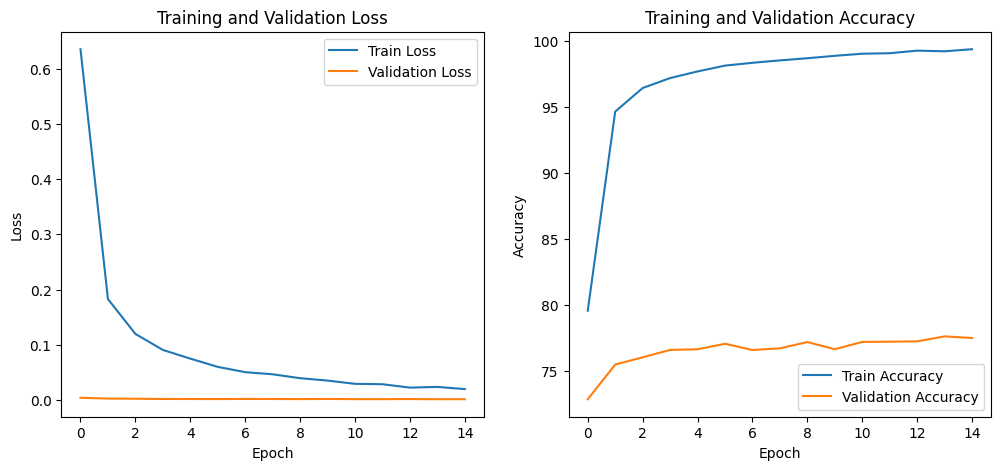

In [99]:
# Plot training and validation loss
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

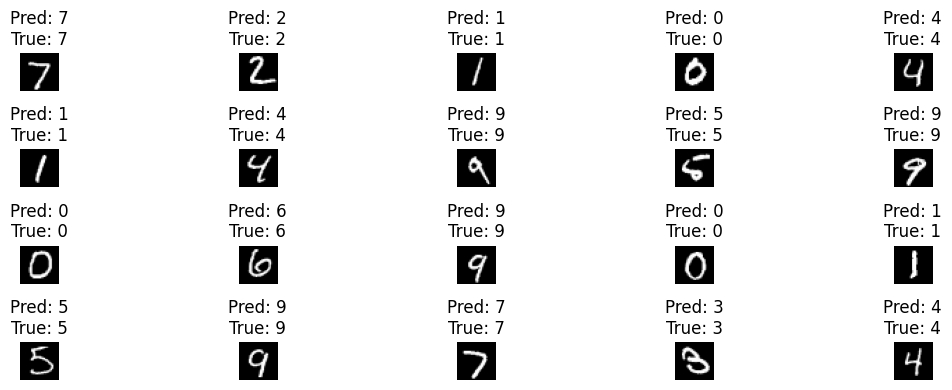

In [100]:
model.eval()
images, labels = next(iter(val_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    outputs = model(images)
    preds = outputs.argmax(dim=1)

# Plot 10 test images with predictions
plt.figure(figsize=(12, 4))
for i in range(20):
    plt.subplot(4, 5, i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(f"Pred: {preds[i].item()}\nTrue: {labels[i].item()}")
    plt.axis('off')
plt.tight_layout()
plt.show()